In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')


plt.style.use('ggplot')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.unicode_minus'] = False
#plt.rcParams['font.sans-serif'] = ['SimHei']

# Transformer结构

- 整体结构：

    网络结构主要由编码器和解码器两部分组成，结构基本同Seq2Seq，主要区别如下：
    * 原始输入中增加位置编码特征向量(绝对位置特征向量);
    * 内部基于 Multi Head Self-Attention + FFN 提取特征向量；
    * 使用残差结构，防止模型退化；
    * 使用Norm结果，提升模型训练效率及防止模型过拟合；

- 编码器

    输入\[bs,et]形状的原始输入token id列表，得到每个token对应的高阶特征向量以及每个文本对应的文本特征向量；bs表示一个批次中存在bs个样本，每个样本由et个token组成，__PS:每个样本实际token数目不一致，所以一个批次中可能存在填充数据；__

    案例：一个样本、5个token组成的输入数据```[[12,35,26,34,253]]```

- 解码器

    输入\[bs,dt]形状的解码器token id列表，对应实际token id列表shape也是\[bs,dt]，并且解码器的输入和解码器的输出恰好有一个位置的错位，并且解码器的第一个时刻的输入和最后一个时刻的输出一般都是特殊token id；bs表示一个批次中存在bs个样本，每个样本由dt个token组成，__PS:每个样本实际token数目不一致，所以一个批次中可能存在填充数据；__

    __NOTE:解码器必须为单向结构__ 

    案例：一个样本，6个token组成的解码器数据：

        解码器输入：[[3,102,235,1523,2132,1243]]
        解码器输出：[[102,235,1523,2132,1243,4]]

## 多头Self-Attention

In [3]:
class MultiHeadSelfAttentionModule(nn.Module):
    def __init__(self, hidden_size, num_header):
        super().__init__()

        header_dim = hidden_size // num_header
        self.num_header = num_header
        self.header_dim = header_dim
        self.q_linear = nn.Linear(hidden_size, header_dim * num_header, bias=False)
        self.k_linear = nn.Linear(hidden_size, header_dim * num_header, bias=False)
        self.v_linear = nn.Linear(hidden_size, header_dim * num_header, bias=False)
        self.wo_linear = nn.Linear(header_dim * num_header, hidden_size)

    def reshape_and_permute(self, v):
        bs, t, _ = v.shape
        # [bs,t,e,h]
        v = torch.reshape(v, (bs, t, -1, self.num_header))
        # [bs,t,e,h] -> [bs,h,t,e]
        return torch.permute(v, dims=(0, 3, 1, 2))

    def permute_and_reshape(self, v):
        bs,h,t,e = v.shape
        # [bs,h,t,e] -> [bs,t,e,h]
        v = torch.permute(v, dims=(0, 2, 3, 1))
        # [bs,t,e,h] -> [bs,t,e*h]
        return torch.reshape(v, (bs, t, -1))
    
    def forward(self, x, x_masked=None):
        """
            多头Self-Attention前向执行逻辑
            :x [bs,t,v] 原始特征 bs个样本，每个样本t个token，每个token对应v维向量
            :x_masked [bs,1,?,t] masked矩阵 用来给定query和key之间能够进行attention计算的关系，0表示可以计算，-inf表示不可以计算相关性

            总运算量:
                bs * h * e * (t * t * 2 + t * v * 4)
        """
        # 1. 获取q/k/v, shape均为: [bs,h,t,e]
        q = self.reshape_and_permute(self.q_linear(x)) # [bs,t,v] * [v,e*h] ---> 浮点运算量: t * v * e * h * bs
        k = self.reshape_and_permute(self.q_linear(x)) # [bs,t,v] * [v,e*h] ---> 浮点运算量: t * v * e * h * bs
        v = self.reshape_and_permute(self.q_linear(x)) # [bs,t,v] * [v,e*h] ---> 浮点运算量: t * v * e * h * bs

        # 2. 计算相关性
        # [bs,h,t,e] * [bs,h,e,t] -> [bs,h,t,t]
        # 每个样本、每个头里面的每个query和其它t个key之间的相关性
        # 浮点运算量: bs * h * t * e * t
        score = torch.matmul(q, torch.transpose(k, dim0=-1, dim1=-2))
        score = score / np.sqrt(self.header_dim)
        if x_masked is not None:
            # 将能够计算attention的对应位置设置为原始值，将不能计算attention的直接设置为-inf（负无穷大）
            # [bs,h,t,t] + [bs,1,t,t] 或者 [bs,h,t,t] + [bs,1,1,t]
            score = score + x_masked

        # 3. 获取权重系数
        alpha = torch.softmax(score, dim=-1) # [bs,h,t,t]
        print(alpha)

        # 4. 加权value
        # [bs,h,t,t] * [bs,h,t,e] --> [bs,h,t,e]
        # 浮点运算量: bs * h * t * t * e
        value = torch.matmul(alpha, v)

        # 5. 合并多个头的数据
        # [bs,t,e*h] * [e*h,v] ---> 浮点运算量: t * e * h * v * bs
        value = self.wo_linear(self.permute_and_reshape(value))
        
        return value

In [4]:
atten = MultiHeadSelfAttentionModule(128, 4)

x = torch.randn(4, 5, 128)
r = atten(x) # 合并后的结果
print(r.shape)

tensor([[[[0.4738, 0.1183, 0.1630, 0.0910, 0.1539],
          [0.1437, 0.5285, 0.1215, 0.1196, 0.0867],
          [0.1427, 0.0875, 0.5488, 0.0920, 0.1289],
          [0.1242, 0.1343, 0.1434, 0.4813, 0.1168],
          [0.1008, 0.0467, 0.0965, 0.0561, 0.6999]],

         [[0.6388, 0.0894, 0.0850, 0.0682, 0.1185],
          [0.1523, 0.5777, 0.0567, 0.0648, 0.1484],
          [0.1764, 0.0690, 0.4467, 0.1904, 0.1175],
          [0.1873, 0.1045, 0.2520, 0.3308, 0.1253],
          [0.1300, 0.0956, 0.0622, 0.0501, 0.6622]],

         [[0.5927, 0.0979, 0.0793, 0.0648, 0.1653],
          [0.1734, 0.5152, 0.0778, 0.0645, 0.1691],
          [0.1556, 0.0861, 0.6018, 0.1059, 0.0506],
          [0.1195, 0.0672, 0.0996, 0.5990, 0.1147],
          [0.0846, 0.0489, 0.0132, 0.0318, 0.8215]],

         [[0.6001, 0.0991, 0.0330, 0.1046, 0.1631],
          [0.1360, 0.5664, 0.0503, 0.0578, 0.1896],
          [0.0812, 0.0901, 0.5989, 0.0914, 0.1383],
          [0.0811, 0.0327, 0.0288, 0.7649, 0.0925],
      

## 多头Cross-Attention

In [5]:
class MultiHeadCrossAttentionModule(nn.Module):
    def __init__(self, hidden_size, num_header):
        super().__init__()

        header_dim = hidden_size // num_header
        self.num_header = num_header
        self.header_dim = header_dim
        self.q_linear = nn.Linear(hidden_size, header_dim * num_header, bias=False)
        self.k_linear = nn.Linear(hidden_size, header_dim * num_header, bias=False)
        self.v_linear = nn.Linear(hidden_size, header_dim * num_header, bias=False)
        self.wo_linear = nn.Linear(header_dim * num_header, hidden_size)

    def reshape_and_permute(self, v):
        bs, t, _ = v.shape
        # [bs,t,e,h]
        v = torch.reshape(v, (bs, t, -1, self.num_header))
        # [bs,t,e,h] -> [bs,h,t,e]
        return torch.permute(v, dims=(0, 3, 1, 2))

    def permute_and_reshape(self, v):
        bs,h,t,e = v.shape
        # [bs,h,t,e] -> [bs,t,e,h]
        v = torch.permute(v, dims=(0, 2, 3, 1))
        # [bs,t,e,h] -> [bs,t,e*h]
        return torch.reshape(v, (bs, t, -1))
    
    def forward(self, x, encoder_state, encoder_masked=None):
        """
            多头Self-Attention前向执行逻辑
            :x [bs,dt,v] 解码器状态 原始特征 bs个样本，每个样本dt个token，每个token对应v维向量
            :encoder_state [bs,et,v] 编码器输出状态 bs个样本，每个样本et个token，每个token对应v维向量
            :encoder_masked [bs,1,1,et] masked矩阵 用来给定query和key之间能够进行attention计算的关系，0表示可以计算，-inf表示不可以计算相关性
        """
        # 1. 获取q/k/v, shape均为: [bs,h,?t,e]
        q = self.reshape_and_permute(self.q_linear(x)) # [bs,h,dt,e]
        k = self.reshape_and_permute(self.q_linear(encoder_state)) # [bs,h,et,e]
        v = self.reshape_and_permute(self.q_linear(encoder_state)) # [bs,h,et,e]

        # 2. 计算相关性
        # [bs,h,dt,e] * [bs,h,e,et] -> [bs,h,dt,et]
        # 每个样本、每个头里面的每个query和其它et个key之间的相关性
        score = torch.matmul(q, torch.transpose(k, dim0=-1, dim1=-2))
        score = score / np.sqrt(self.header_dim)
        if encoder_masked is not None:
            # 将能够计算attention的对应位置设置为原始值，将不能计算attention的直接设置为-inf（负无穷大）
            score = score + encoder_masked

        # 3. 获取权重系数
        alpha = torch.softmax(score, dim=-1) # [bs,h,dt,et]

        # 4. 加权value
        # [bs,h,dt,et] * [bs,h,et,e] --> [bs,h,dt,e]
        value = torch.matmul(alpha, v)

        # 5. 合并多个头的数据 [bs,dt,v]
        value = self.wo_linear(self.permute_and_reshape(value))
        
        return value

In [6]:
atten = MultiHeadCrossAttentionModule(128, 4)

x = torch.randn(4, 5, 128)
encoder_state = torch.randn(4, 10, 128)
r = atten(x, encoder_state) # 合并后的结果
print(r.shape)

torch.Size([4, 5, 128])


## FFN全连接

In [7]:
class FNNModule(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()


        self.fc1 = nn.Linear(hidden_size, hidden_size * 4)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_size * 4, hidden_size)

    def forward(self, x):
        # 运算量: bs * t * v * 4v  * 2
        return self.fc2(self.act(self.fc1(x)))

In [8]:
ffn = FNNModule(128)
x = torch.rand(2, 5, 128)
r = ffn(x)
print(x.shape)

torch.Size([2, 5, 128])


## Transformer Layer层

In [9]:
class TransformerLayer(nn.Module):
    def __init__(self, hidden_size, num_header, is_decoder=False):
        super().__init__()

        self.is_decoder = is_decoder
        self.self_atten = MultiHeadSelfAttentionModule(hidden_size, num_header)
        self.self_atten_norm = nn.LayerNorm(hidden_size)
        if is_decoder:
            self.cross_atten = MultiHeadCrossAttentionModule(hidden_size, num_header)
            self.cross_atten_norm = nn.LayerNorm(hidden_size)
        self.ffn = FNNModule(hidden_size)
        self.ffn_norm = nn.LayerNorm(hidden_size)

    def forward(self, x, x_masked=None, encoder_state=None, encoder_masked=None):
        """
            前向执行
        """
        # 1. self-attention
        indentity = x
        x = self.self_atten(x, x_masked)
        x = indentity + x
        x = self.self_atten_norm(x)

        # 2. cross-attention
        if self.is_decoder:
            indentity = x
            x = self.cross_atten(x, encoder_state, encoder_masked)
            x = indentity + x
            x = self.cross_atten_norm(x)

        # 3. FFN
        indentity = x
        x = self.ffn(x)
        x = self.ffn_norm(indentity + x)

        return x

In [10]:
# 编码器层执行操作
layer = TransformerLayer(hidden_size=128, num_header=4, is_decoder=False)

x = torch.rand(2, 5, 128)
r = layer(x)
print(r.shape)


tensor([[[[0.2324, 0.2023, 0.2034, 0.1750, 0.1869],
          [0.2052, 0.2230, 0.2078, 0.1743, 0.1897],
          [0.2014, 0.2030, 0.2260, 0.1807, 0.1888],
          [0.1960, 0.1925, 0.2044, 0.2050, 0.2022],
          [0.1950, 0.1951, 0.1988, 0.1882, 0.2229]],

         [[0.2199, 0.1922, 0.1775, 0.2080, 0.2024],
          [0.1744, 0.2488, 0.1717, 0.1975, 0.2077],
          [0.1757, 0.1873, 0.2228, 0.2072, 0.2070],
          [0.1791, 0.1876, 0.1804, 0.2372, 0.2157],
          [0.1736, 0.1964, 0.1795, 0.2148, 0.2357]],

         [[0.2608, 0.1886, 0.1833, 0.1928, 0.1745],
          [0.2138, 0.2302, 0.1842, 0.1868, 0.1850],
          [0.2199, 0.1950, 0.2159, 0.1805, 0.1886],
          [0.2295, 0.1962, 0.1790, 0.2094, 0.1859],
          [0.2065, 0.1931, 0.1860, 0.1848, 0.2296]],

         [[0.2451, 0.1986, 0.1848, 0.1755, 0.1960],
          [0.2046, 0.2234, 0.1827, 0.1854, 0.2038],
          [0.2079, 0.1995, 0.2153, 0.1880, 0.1893],
          [0.1933, 0.1983, 0.1841, 0.2309, 0.1935],
      

In [11]:
# 解码器层执行操作
layer = TransformerLayer(hidden_size=128, num_header=4, is_decoder=True)

x = torch.rand(2, 6, 128)
x_masked = torch.tensor([
    [1, 0, 0, 0, 0, 0],
    [1, 1, 0, 0, 0, 0],
    [1, 1, 1, 0, 0, 0],
    [1, 1, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1],
], dtype=torch.float32)
x_masked = (1.0 - x_masked) * torch.finfo(torch.float32).min
x_masked = x_masked[None, None]
encoder_state = torch.rand(2, 5, 128)
r = layer(x, x_masked=x_masked, encoder_state = encoder_state)
print(r.shape)


tensor([[[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.4274, 0.5726, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.3027, 0.3396, 0.3577, 0.0000, 0.0000, 0.0000],
          [0.2276, 0.2462, 0.2107, 0.3156, 0.0000, 0.0000],
          [0.1766, 0.2092, 0.1820, 0.1965, 0.2357, 0.0000],
          [0.1567, 0.1739, 0.1568, 0.1727, 0.1726, 0.1672]],

         [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.4758, 0.5242, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.3334, 0.3150, 0.3516, 0.0000, 0.0000, 0.0000],
          [0.2515, 0.2395, 0.2380, 0.2710, 0.0000, 0.0000],
          [0.2040, 0.1928, 0.1821, 0.1859, 0.2352, 0.0000],
          [0.1770, 0.1632, 0.1599, 0.1618, 0.1615, 0.1766]],

         [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.4869, 0.5131, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.3224, 0.3209, 0.3567, 0.0000, 0.0000, 0.0000],
          [0.2479, 0.2468, 0.2350, 0.2703, 0.0000, 0.0000],
          [0.2010, 0.1943, 0.1906, 0

## Token Embedding层

In [20]:
# 单词Token Embedding
class WordEmbedding(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_size)

    def forward(self, token_ids):
        return self.emb(token_ids) # [bs,t] -> [bs,t,e]

## Token Position Embedding层

In [12]:
# 位置Embedding
class PositionEmbedding(nn.Module):
    """
        Transformer论文中的原始默认位置编码：正弦余弦绝对位置编码
            PE(pos, 2i) = sin(pos / 10000^(2i/d_model)) --> 偶数位置使用sin
            PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model)) --> 奇数位置使用cos
        NOTE:
            pos: 就是token的位置编码, 最小为0，最大为: max_position-1
            d_model: 就是每个位置映射的向量维度大小，也就是: hidden_size
            i: 就是每个位置映射向量的每个分量位置，取值: [0, hidden_size)
    """
    def __init__(self, max_position, hidden_size):
        super().__init__()

        position = torch.arange(max_position).unsqueeze(1) # [max_position, 1]
        div_term = torch.pow(10000, torch.arange(0, hidden_size, 2) / hidden_size).unsqueeze(0) # [1, hidden_size/2]
        

        pe = torch.zeros(max_position, hidden_size) # shape就是[max_position, hidden_size]
        pe[:, 0::2] = torch.sin(position / div_term)
        pe[:, 1::2] = torch.cos(position / div_term)

        # 注册后，会随着模型参数进行持久化，但是不会参与模型训练
        self.register_buffer("pe", pe)

        
    def forward(self, token_ids):
        bs, t = token_ids.shape

        token_index_emb = self.pe[:t] # [t,e]
        token_index_emb = token_index_emb.unsqueeze(0) # [1,t,e]
        token_index_emb = torch.tile(token_index_emb, (bs,1,1)) 
        
        return token_index_emb

In [13]:
def plot_heatmap(pe_matrix, title, figsize=(10, 6)):
    """绘制位置编码矩阵的热力图（每行一个位置，每列一个维度）"""
    plt.figure(figsize=figsize)
    max_len, d_model = pe_matrix.shape
    # 热力图：x轴为维度，y轴为位置
    plt.imshow(pe_matrix, cmap="viridis", aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xticks(np.arange(0, d_model, step=100))  # 每隔10个维度标刻度
    plt.yticks(np.arange(0, max_len, step=100))   # 每隔5个位置标刻度
    plt.tight_layout()
    plt.show()

In [16]:
position = PositionEmbedding(512, 768)

token_ids = torch.tensor([
    [2,3,5],
    [6,5,8]
])
r = position(token_ids)
print(r.shape)
print(r)

torch.Size([2, 3, 768])
tensor([[[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00],
         [ 8.4147e-01,  5.4030e-01,  8.2843e-01,  ...,  1.0000e+00,
           1.0243e-04,  1.0000e+00],
         [ 9.0930e-01, -4.1615e-01,  9.2799e-01,  ...,  1.0000e+00,
           2.0486e-04,  1.0000e+00]],

        [[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  ...,  1.0000e+00,
           0.0000e+00,  1.0000e+00],
         [ 8.4147e-01,  5.4030e-01,  8.2843e-01,  ...,  1.0000e+00,
           1.0243e-04,  1.0000e+00],
         [ 9.0930e-01, -4.1615e-01,  9.2799e-01,  ...,  1.0000e+00,
           2.0486e-04,  1.0000e+00]]])


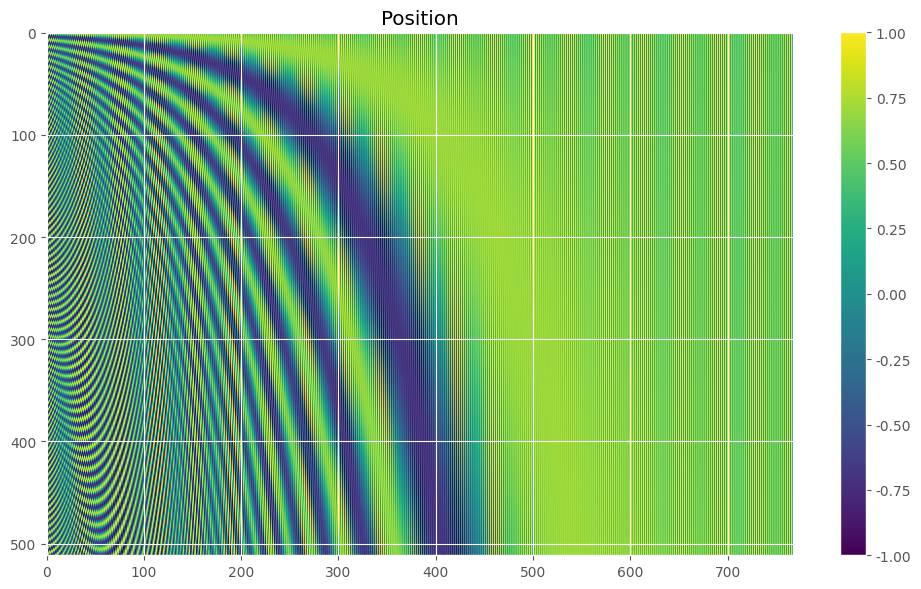

In [17]:
plot_heatmap(position.pe, title='Position')

## Embedding层

In [21]:
# Embedding层
class TransformerEmbedding(nn.Module):
    def __init__(self, vocab_size, max_position, hidden_size):
        super().__init__()

        self.token_emb_layer = WordEmbedding(vocab_size, hidden_size)
        self.position_emb_layer = PositionEmbedding(max_position, hidden_size)
        self.norm = nn.LayerNorm(hidden_size)

    def forward(self, token_ids):
        token_emb = self.token_emb_layer(token_ids)
        position_emb = self.position_emb_layer(token_ids)
        emb = self.norm(token_emb + position_emb)
        return emb

In [22]:
emb_layer = TransformerEmbedding(1000, 512, 8)

token_ids = torch.tensor([
    [2,3,4],
    [2,4,3]
])
r = emb_layer(token_ids)
print(r.shape)
print(r)

torch.Size([2, 3, 8])
tensor([[[-1.5440,  0.7159, -0.4060, -0.4357,  0.0945,  1.3607, -1.0896,
           1.3043],
         [-0.4788, -0.2068, -1.7712,  1.0998, -0.5928,  1.5824, -0.2952,
           0.6624],
         [-0.4229, -1.2813,  0.8069,  1.2675, -0.4784,  0.3195, -1.4414,
           1.2300]],

        [[-1.5440,  0.7159, -0.4060, -0.4357,  0.0945,  1.3607, -1.0896,
           1.3043],
         [-0.6322, -0.5948,  0.7057,  1.3283, -0.6380,  0.2594, -1.7004,
           1.2721],
         [-0.3297, -0.8877, -1.5565,  1.1327, -0.4865,  1.6120, -0.2055,
           0.7211]]], grad_fn=<NativeLayerNormBackward0>)


## Encoder编码器

In [23]:
# 编码器
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, max_position, hidden_size, num_header, num_layers):
        super().__init__()

        self.emb_layer = TransformerEmbedding(vocab_size, max_position, hidden_size)

        self.layers = nn.ModuleList([
            TransformerLayer(hidden_size, num_header, is_decoder=False) for _ in range(num_layers)
        ])

    def forward(self, encoder_token_ids, encoder_token_mask=None):
        """
            编码器层重叠
            : encoder_token_ids [bs,t] 编码器输入token id列表
            : encoder_token_mask [bs,t] 输入token填充信息 实际token位置为1，填充位置为0
        """
        # [bs,t] -> [bs,t,e]
        token_emb = self.emb_layer(encoder_token_ids)

        # 构造编码器self-attention计算过程中的mask矩阵
        encoder_attention_mask = None
        if encoder_token_mask is not None:
            encoder_attention_mask = encoder_token_mask[:, None, None]
            fmin = torch.finfo(token_emb.dtype).min
            encoder_attention_mask = (1 -encoder_attention_mask) * fmin

        for layer in self.layers:
            # x, =None, encoder_state=None, encoder_masked=None
            token_emb = layer(
                x = token_emb, # 当前层的输入token向量 [bs,t,e]
                x_masked = encoder_attention_mask # 计算self-attention时候的mask矩阵 [bs,1,t,t]
            )
        return token_emb


In [24]:
encoder = TransformerEncoder(
    vocab_size=1000, 
    max_position=512, 
    hidden_size=32, 
    num_header=2, 
    num_layers=3
)
print(encoder)

token_ids = torch.tensor([
    [25, 35, 21, 12, 0, 0], 
    [12, 22, 34, 15, 45, 16]
])
token_masks = torch.tensor([
    [1, 1, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 1]
])
r = encoder(token_ids, token_masks)
print(r.shape)

TransformerEncoder(
  (emb_layer): TransformerEmbedding(
    (token_emb_layer): WordEmbedding(
      (emb): Embedding(1000, 32)
    )
    (position_emb_layer): PositionEmbedding()
    (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  )
  (layers): ModuleList(
    (0-2): 3 x TransformerLayer(
      (self_atten): MultiHeadSelfAttentionModule(
        (q_linear): Linear(in_features=32, out_features=32, bias=False)
        (k_linear): Linear(in_features=32, out_features=32, bias=False)
        (v_linear): Linear(in_features=32, out_features=32, bias=False)
        (wo_linear): Linear(in_features=32, out_features=32, bias=True)
      )
      (self_atten_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): FNNModule(
        (fc1): Linear(in_features=32, out_features=128, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=128, out_features=32, bias=True)
      )
      (ffn_norm): LayerNorm((32,), eps=1e-05, elementwise_affine

## Decoder解码器

In [25]:
# 解码器
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, max_position, hidden_size, num_header, num_layers):
        super().__init__()

        self.emb_layer = TransformerEmbedding(vocab_size, max_position, hidden_size)

        self.layers = nn.ModuleList([
            TransformerLayer(hidden_size, num_header, is_decoder=True) for _ in range(num_layers)
        ])

    def forward(self, 
                decoder_token_ids, decoder_token_mask=None, 
                encoder_token_mask=None,
                encoder_state=None, decoder_encoder_attention_mask=None
               ):
        """
            编码器层重叠
            : decoder_token_ids [bs,dt] 解码器输入token id
            : decoder_token_mask [bs,dt] 解码器输入token填充信息，填充位置为0，真实token位置为1
            : encoder_token_mask [bs,et] 编码器输入token填充信息，填充位置为0，真实token位置为1
            : encoder_state [bs,et,e] 编码器输出特征
            : decoder_encoder_attention_mask [bs,1,1,et] 解码器-编码器attention计算过程中的mask矩阵,0表示计算，负无穷大表示不计算
        """
        # token embedding 
        token_emb = self.emb_layer(decoder_token_ids)

        # attention mask矩阵计算
        fmin = torch.finfo(token_emb.dtype).min
        if decoder_encoder_attention_mask is None:
            if encoder_token_mask is None:
                decoder_encoder_attention_mask = encoder_token_mask[:, None, None]
                decoder_encoder_attention_mask = (1 -decoder_encoder_attention_mask) * fmin
        # 上三角矩阵
        bs, t, e = token_emb.shape
        # 主对角线右上方全部为0，其它位置全部为1
        decoder_self_attention_mask = torch.tril(torch.ones((t,t)), diagonal=0)
        decoder_self_attention_mask = decoder_self_attention_mask[None, None] # [1,1,t,t]
        if decoder_token_mask is not None:
            # [bs,1,1,t]
            decoder_self_attention_mask_ = decoder_token_mask[:, None, None]
            decoder_self_attention_mask = decoder_self_attention_mask * decoder_self_attention_mask_
        decoder_self_attention_mask = (1 - decoder_self_attention_mask) * fmin
        
        for layer in self.layers:
            token_emb = layer(
                x=token_emb, 
                x_masked=decoder_self_attention_mask, 
                encoder_state=encoder_state, 
                encoder_masked=decoder_encoder_attention_mask
            )
        return token_emb

In [26]:
decoder = TransformerDecoder(
    vocab_size=1000, 
    max_position=512, 
    hidden_size=128, 
    num_header=4, 
    num_layers=3
)
print(decoder)

decoder_token_ids = torch.tensor([
    [1,2,3,0,0],
    [1,6,5,2,3]
])
decoder_token_mask = torch.tensor([
    [1,1,1,0,0],
    [1,1,1,1,1]
])
encoder_token_mask = torch.tensor([
    [1, 1, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 1]
])
encoder_state = torch.rand(2, 6, 128)
r = decoder(
    decoder_token_ids=decoder_token_ids, 
    decoder_token_mask=decoder_token_mask, 
    encoder_token_mask=encoder_token_mask,
    encoder_state=encoder_state, 
    decoder_encoder_attention_mask=None
)
print(r.shape)

TransformerDecoder(
  (emb_layer): TransformerEmbedding(
    (token_emb_layer): WordEmbedding(
      (emb): Embedding(1000, 128)
    )
    (position_emb_layer): PositionEmbedding()
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): ModuleList(
    (0-2): 3 x TransformerLayer(
      (self_atten): MultiHeadSelfAttentionModule(
        (q_linear): Linear(in_features=128, out_features=128, bias=False)
        (k_linear): Linear(in_features=128, out_features=128, bias=False)
        (v_linear): Linear(in_features=128, out_features=128, bias=False)
        (wo_linear): Linear(in_features=128, out_features=128, bias=True)
      )
      (self_atten_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (cross_atten): MultiHeadCrossAttentionModule(
        (q_linear): Linear(in_features=128, out_features=128, bias=False)
        (k_linear): Linear(in_features=128, out_features=128, bias=False)
        (v_linear): Linear(in_features=128, out_features=12

## Transformer合并结构

In [27]:
class Transformer(nn.Module):
    def __init__(self, 
                 vocab_size, max_position, hidden_size, 
                 encoder_num_header, encoder_num_layers, 
                 decoder_num_header, decoder_num_layers
                ):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size, max_position, hidden_size, encoder_num_header, encoder_num_layers
        )
        self.decoder = TransformerDecoder(
            vocab_size, max_position, hidden_size, decoder_num_header, decoder_num_layers
        )
        self.classify = nn.Linear(hidden_size, vocab_size)

    def forward(self, 
                encoder_token_ids=None,  # [bs,et] 编码器输入token id列表
                encoder_masked=None, # [bs,et] 编码器输入token填充信息，真实token位置为1，填充token位置为0
                decoder_token_ids=None, # [bs,dt] 解码器输入token id列表
                decoder_masked=None # [bs,dt] 解码器输入token
               ):
        # 1. 编码器执行
        encoder_state = self.encoder(
            encoder_token_ids = encoder_token_ids, 
            encoder_token_mask = encoder_masked
        )

        # 2. 解码器执行
        decoder_state = self.decoder(
            decoder_token_ids = decoder_token_ids, 
            decoder_token_mask = decoder_masked,
            encoder_token_mask = encoder_masked,
            encoder_state = encoder_state, 
            decoder_encoder_attention_mask = None
        )

        # 3. 输出所属类别置信度
        score = self.classify(decoder_state)

        return score

In [28]:
net = Transformer(
    vocab_size=100, max_position=64, hidden_size=16,
    encoder_num_header=8, encoder_num_layers=6, 
    decoder_num_header=8, decoder_num_layers=6
)
print(net)

decoder_token_ids = torch.tensor([
    [1,2,3,0,0],
    [1,6,5,2,3]
])
decoder_masked = torch.tensor([
    [1,1,1,0,0],
    [1,1,1,1,1]
])
encoder_masked = torch.tensor([
    [1, 1, 1, 1, 0, 0],
    [1, 1, 1, 1, 1, 1]
])
encoder_token_ids = torch.tensor([
    [25, 35, 21, 12, 0, 0], 
    [12, 22, 34, 15, 45, 16]
])
r = net(
    encoder_token_ids=encoder_token_ids,
    encoder_masked=encoder_masked,
    decoder_token_ids=decoder_token_ids,
    decoder_masked=decoder_masked
)
print(r.shape)

Transformer(
  (encoder): TransformerEncoder(
    (emb_layer): TransformerEmbedding(
      (token_emb_layer): WordEmbedding(
        (emb): Embedding(100, 16)
      )
      (position_emb_layer): PositionEmbedding()
      (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0-5): 6 x TransformerLayer(
        (self_atten): MultiHeadSelfAttentionModule(
          (q_linear): Linear(in_features=16, out_features=16, bias=False)
          (k_linear): Linear(in_features=16, out_features=16, bias=False)
          (v_linear): Linear(in_features=16, out_features=16, bias=False)
          (wo_linear): Linear(in_features=16, out_features=16, bias=True)
        )
        (self_atten_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (ffn): FNNModule(
          (fc1): Linear(in_features=16, out_features=64, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=64, out_features=16, bias=True)
        )